# Problem Statement

Climate change misinformation spreads widely through social media, blogs, and news articles. False claims such as “climate change is a hoax” can influence public opinion and hinder climate action.

The goal of this project is to build an AI/NLP model that automatically detects whether a climate-related statement is:

- Misinformation
- Factual

The system processes textual statements using Natural Language Processing (NLP) techniques and classifies them using Machine Learning models.

The project demonstrates the complete NLP pipeline:

> Dataset → Text preprocessing → Feature extraction → Model training → Evaluation → Prediction.

Datasets for this project typically contain text statements and labels such as misinformation or factual.

# Datasets

A suitable dataset for this project is the Climate Change Tweets Dataset, which contains climate-related claims and their truth labels.

```s
| text                           | label          |
| ------------------------------ | -------------- |
| Climate change is fake         | misinformation |
| Rising CO2 causes warming      | factual        |
| Global warming stopped in 1998 | misinformation |
```

Database File Name: climate_data.csv

## Installing Packages

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn kagglehub --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Importing Libraries & Downloading NLTK Resources

In [2]:
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns

'''
    Download required NLTK resources in one loop
    punkt: Tokenizer models for splitting text into words
    stopwords: List of common words to remove from text
    wordnet: Lexical database for English used for lemmatization & synonymnym lookup
    omw-1.4: Open Multilingual Wordnet for extended lemmatization support
'''
for resource in ("punkt", "stopwords", "wordnet", "omw-1.4"):
    nltk.download(resource)

from nltk.tokenize import word_tokenize # Tokenizer for splitting text into words
from nltk.corpus import stopwords # List of common words to remove from text
from nltk.stem import WordNetLemmatizer # Lemmatizer for reducing words to their base form

from sklearn.feature_extraction.text import TfidfVectorizer # vectorizer to convert text to numerical features
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier for text classification
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Dataset Loading

In [3]:
# Load synthetic climate dataset in required format: text,label
data = pd.read_csv("climate_data.csv")

# Basic cleanup
data["text"] = data["text"].astype(str).str.strip()
data["label"] = data["label"].astype(str).str.strip().str.lower()
data = data[data["label"].isin(["misinformation", "factual"])]
data = data[data["text"].str.len() > 0].drop_duplicates().reset_index(drop=True)

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (1762, 2)
                                                text           label
0  Cold winters disprove fossil fuel use in local...  misinformation
1  Clean energy helps limit drivers of ocean warm...         factual
2  Carbon emissions is just natural variation in ...  misinformation
3  Policies on greenhouse gases are unnecessary i...  misinformation
4  Observations indicate measurable changes in gl...         factual


## Explore Dataset


Class Distribution:
label
misinformation    889
factual           873
Name: count, dtype: int64


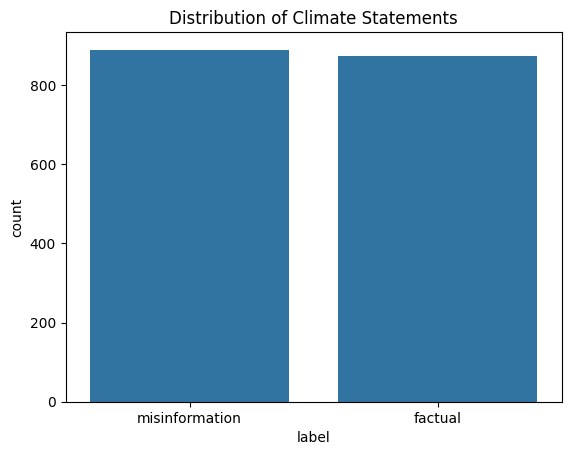

In [4]:
print("\nClass Distribution:")
print(data['label'].value_counts())

# Plot label distribution
sns.countplot(x='label', data=data)
plt.title("Distribution of Climate Statements")
plt.show()

## NLP Preprocessing with NLTK

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back
    return " ".join(tokens)

## Preprocessing

In [6]:
# Ensure tokenizer tables required by newer NLTK versions are available
try:
    nltk.data.find("tokenizers/punkt_tab/english/")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

data['clean_text'] = data['text'].apply(preprocess_text)
print(data[['text','clean_text']].head())

                                                text  \
0  Cold winters disprove fossil fuel use in local...   
1  Clean energy helps limit drivers of ocean warm...   
2  Carbon emissions is just natural variation in ...   
3  Policies on greenhouse gases are unnecessary i...   
4  Observations indicate measurable changes in gl...   

                                          clean_text  
0  cold winter disprove fossil fuel use local obs...  
1  clean energy help limit driver ocean warming u...  
2    carbon emission natural variation recent report  
3  policy greenhouse gas unnecessary long-term re...  
4  observation indicate measurable change global ...  


## Word Frequency Visualization

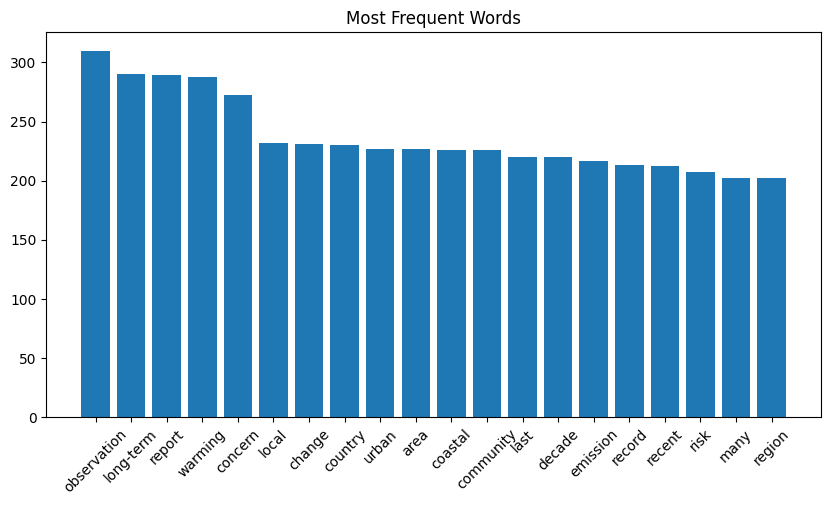

In [7]:
from collections import Counter

all_words = " ".join(data['clean_text']).split()

word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.show()

## Convert Text to TF-IDF (Term Frequency-Inverse Document Frequency)

In [8]:
vectorizer = TfidfVectorizer() # vectorizer to convert text to numerical features

X = vectorizer.fit_transform(data['clean_text'])
y = data['label']

## Data Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Models

In [10]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Evaluation


Naive Bayes Performance
Accuracy: 0.7252124645892352
Precision: 0.6834862385321101
Recall: 0.8418079096045198
F1 Score: 0.7544303797468355


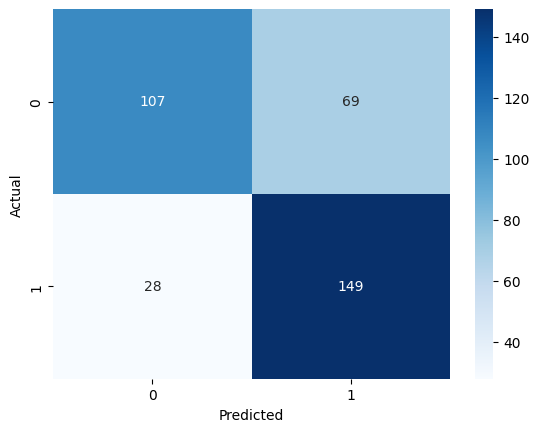


Logistic Regression Performance
Accuracy: 0.7195467422096318
Precision: 0.6989795918367347
Recall: 0.7740112994350282
F1 Score: 0.7345844504021448


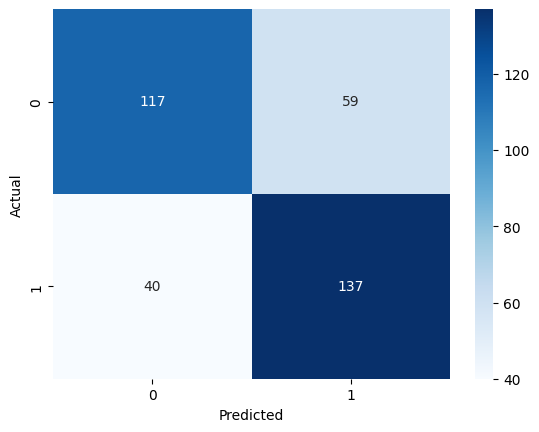

In [11]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='misinformation')
    rec = recall_score(y_test, y_pred, pos_label='misinformation')
    f1 = f1_score(y_test, y_pred, pos_label='misinformation')

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


print("\nNaive Bayes Performance")
evaluate_model(nb_model, X_test, y_test)

print("\nLogistic Regression Performance")
evaluate_model(lr_model, X_test, y_test)

## Model Comparision

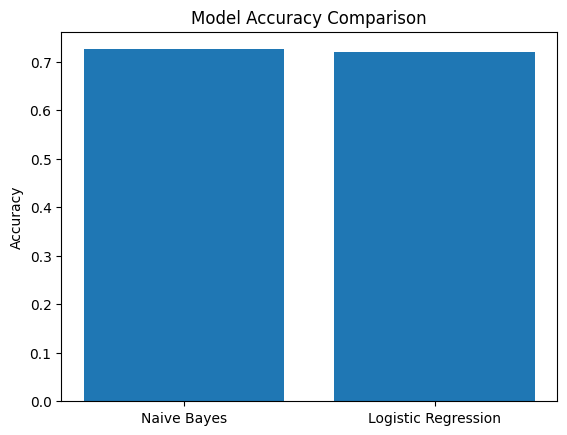

In [12]:
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, nb_model.predict(X_test)),
    accuracy_score(y_test, lr_model.predict(X_test))
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Prediction Function

In [13]:
def predict_statement(statement, model):

    cleaned = preprocess_text(statement)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    print("Statement:", statement)
    print("Prediction:", prediction)

## Sample Predictions

In [14]:
predict_statement(
    "Climate change is a hoax created by scientists",
    lr_model
)

predict_statement(
    "Carbon dioxide emissions increase global temperatures",
    lr_model
)

predict_statement(
    "Renewable energy reduces greenhouse gases",
    lr_model
)

Statement: Climate change is a hoax created by scientists
Prediction: misinformation
Statement: Carbon dioxide emissions increase global temperatures
Prediction: misinformation
Statement: Renewable energy reduces greenhouse gases
Prediction: factual
